# Analyse exploratoire des données marketing

## Objectif
Comprendre les données et analyser ROI.

In [10]:
import os, sys
sys.path.append(os.path.abspath('../src'))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mon_projet.data.load_data import load_raw_data
from mon_projet.data.preprocess import clean_data, create_roi

In [11]:
df = load_raw_data('../data/raw/marketing_and_sales.xls')
df.head()

,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social Media  4566 non-null   float64
 3   Influencer    4572 non-null   object 
 4   Sales         4566 non-null   float64
dtypes: float64(4), object(1)
memory usage: 178.7+ KB


In [13]:
df = clean_data(df)
df = create_roi(df)
df.head()

,TV,Radio,Social Media,Influencer,Sales,ROI
0,16.0,6.566231,2.907983,Mega,54.732757,2.148555
1,13.0,9.237765,2.409567,Mega,46.677897,1.893832
2,41.0,15.886446,2.913410,Mega,150.177829,2.511341
3,83.0,30.020028,6.922304,Mega,298.246340,2.486581
4,15.0,8.437408,1.405998,Micro,56.594181,2.278036


In [14]:
df.describe()

,TV,Radio,Social Media,Sales,ROI
count,4572.000000,4572.000000,4572.000000,4572.000000,4572.000000
mean,53.948600,18.144468,3.319594,192.214021,2.563993
std,26.218437,9.687617,2.214490,93.332457,0.616321
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,10.479564,1.523900,112.200878,2.409032
50%,53.000000,17.845547,3.054085,188.898600,2.552728
75%,77.000000,25.647476,4.805832,272.414914,2.701949
max,100.000000,48.871161,13.981662,364.079751,33.593142


 Interprétation :
 -	TV = canal dominant
 -	Social Media = très faible budget
- ROI → anomalie importante
-	moyenne : 2.56
-	max : 33.59 (!!)
-	min : 0
- Ça c’est un point CRITIQUE.
- Le ROI est très asymétrique et Il y a des valeurs extrêmes (outliers)

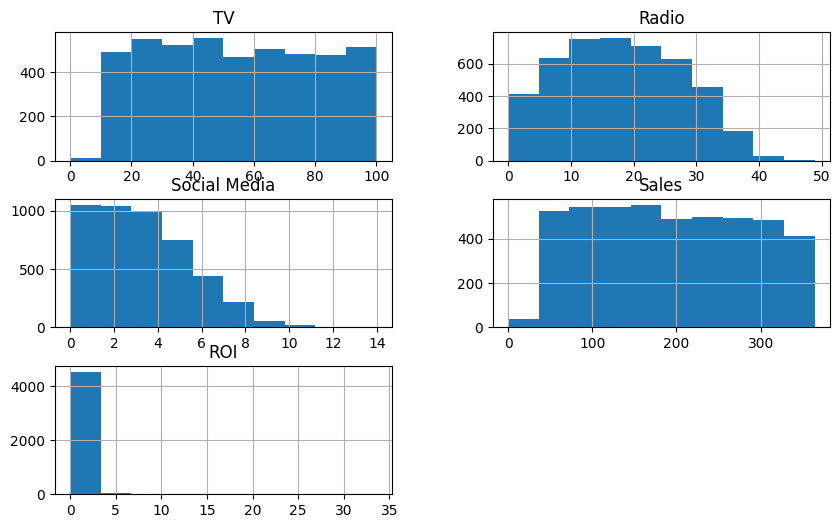

In [15]:
df[['TV','Radio','Social Media','Sales','ROI']].hist(figsize=(10,6))
plt.show()

TV :

→ assez uniforme
👉 pas de problème

Radio :

→ distribution normale
👉 bon signal pour ML

Social Media :

→ biais vers 0
👉 beaucoup de petites valeurs

Sales :

→ assez bien réparti



⚠️ ROI :

👉 énorme concentration vers les petites valeurs
👉 + quelques valeurs énormes

Conclusion importante :

👉 ROI n’est PAS une variable bien distribuée

Ça aura un impact sur :
	•	les modèles
	•	les erreurs
	•	la stabilité

Interprétation :

👉 Les ventes dépendent fortement des budgets marketing
👉 C’est logique → dataset cohérent

Insight clé (très important pour le projet)

👉 Le ROI n’est PAS directement lié aux budgets.

Parce que : ROI = Sales / Budget

Donc :
	•	si on augmentes budget → ROI peut baisser
	•	si budget est faible → ROI peut exploser

👉 Donc le modèle sera plus difficile que pour Sales.

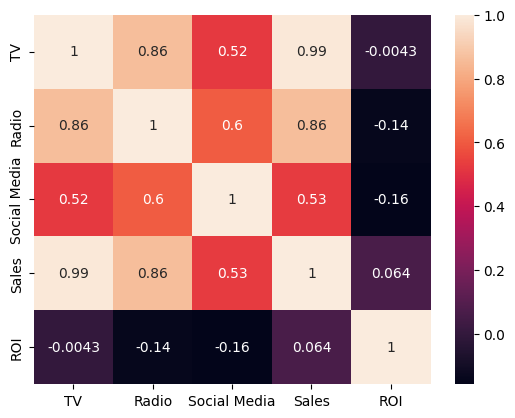

In [16]:
sns.heatmap(df[['TV','Radio','Social Media','Sales','ROI']].corr(), annot=True)
plt.show()

In [17]:
df.groupby('Influencer')[['Sales','ROI']].mean()

,Sales,ROI
Influencer,,
Macro,195.439257,2.598097
Mega,190.264489,2.550268
Micro,191.642739,2.556785
Nano,191.597281,2.551651


In [18]:
df.to_csv('../data/processed/marketing_and_sales_clean.csv', index=False)

Conclusion EDA (tu peux copier)

L’analyse exploratoire montre que les variables budgétaires (TV, Radio, Social Media) sont fortement corrélées aux ventes, en particulier TV et Radio.

En revanche, le ROI présente une distribution très asymétrique avec des valeurs extrêmes, dues à des budgets faibles combinés à des ventes élevées.

Cette caractéristique rend la modélisation du ROI plus complexe que celle des ventes, car il s’agit d’un ratio sensible aux petites variations du dénominateur.

Une attention particulière devra être portée aux outliers et à la transformation de la variable cible lors du preprocessing.